# Principal Recovery Ratio Prediction (LendingClub)

This notebook builds a reproducible preprocessing and modeling pipeline for predicting **principal recovery ratio** using LendingClub loan data.

Target definition:

`principal_recovery_ratio = total_rec_prncp / loan_amnt`

This target measures the proportion of original loan principal recovered. It is more economically interpretable than `total_pymnt / loan_amnt`, which can exceed 1 because total payments include interest and fees.

Outputs:
- `X_train`, `X_val`, `X_test`
- `y_train`, `y_val`, `y_test` for principal recovery ratio
- feature names and split summaries
- loan-level model benchmarks and interpretation


## 1) Setup
Set paths and import dependencies.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)

RAW_DATA_PATH = Path("/Users/peisun/Downloads/archive/loan.csv")
DICT_PATH = Path("/Users/peisun/Downloads/archive/LCDataDictionary.xlsx")
OUT_DIR = Path("milestone/processed_from_notebook")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# For quick debugging, set SAMPLE_ROWS to an integer (e.g., 200000).
SAMPLE_ROWS = None

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {RAW_DATA_PATH}")

print("Raw data:", RAW_DATA_PATH)
print("Data dictionary:", DICT_PATH, "(exists:", DICT_PATH.exists(), ")")
print("Output dir:", OUT_DIR.resolve())

Raw data: /Users/peisun/Downloads/archive/loan.csv
Data dictionary: /Users/peisun/Downloads/archive/LCDataDictionary.xlsx (exists: True )
Output dir: /Users/peisun/berkeley_datasci_207_proj/final/milestone/processed_from_notebook


## 2) Load Data

In [6]:
df = pd.read_csv(RAW_DATA_PATH, low_memory=False, nrows=SAMPLE_ROWS)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
df.head(2)

Shape: (2260668, 145)
Columns: 145


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 3) Target Definition and Outcome Filtering

We keep only loans with final outcomes (`Fully Paid`, `Charged Off`, and `Default`) so the realized principal recovery can be measured. The target is:

`principal_recovery_ratio = total_rec_prncp / loan_amnt`

This target measures how much original loan principal was recovered. Outcome-related columns used to construct the target are excluded from the model features later to avoid leakage.


In [7]:
#  closed loans only (Fully Paid + Charged Off + Default)
FINAL_STATUSES = {"Fully Paid", "Charged Off", "Default"}

# Modeling features only (no target-related columns).
# Expanded pre-origination predictors to improve model signal.
SELECTED_FEATURES = [
    "loan_amnt",
    "grade",
    "sub_grade",
    "term",
    "emp_length",
    "annual_inc",
    "int_rate",
    "installment",
    "home_ownership",
    "dti",
    "earliest_cr_line",
    "open_acc",
    "revol_util",
    "verification_status",
    "purpose",
    "addr_state",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec",
    "revol_bal",
    "total_acc",
    "initial_list_status",
    "collections_12_mths_ex_med",
    "application_type",
    "acc_now_delinq",
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",
]
SPLIT_COL = "issue_d"
TARGET_COLS = ["total_rec_prncp", "loan_amnt"]

available_features = [c for c in SELECTED_FEATURES if c in df.columns]
missing_features = [c for c in SELECTED_FEATURES if c not in df.columns]

if SPLIT_COL not in df.columns:
    raise ValueError(f"Missing required split column: {SPLIT_COL}")
for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f"Missing required column for principal_recovery_ratio: {col}")

if missing_features:
    print("[WARN] Missing requested features in this dataset:", missing_features)

base_cols = list(dict.fromkeys(available_features + [SPLIT_COL] + TARGET_COLS + ["loan_status"]))
base = df[[c for c in base_cols if c in df.columns]].copy()
base = base[base["loan_status"].isin(FINAL_STATUSES)].copy()

# Ensure numeric and valid for division
base["total_rec_prncp"] = pd.to_numeric(base["total_rec_prncp"], errors="coerce")
base["loan_amnt"] = pd.to_numeric(base["loan_amnt"], errors="coerce")
base = base[base["loan_amnt"] > 0].copy()
base["principal_recovery_ratio"] = base["total_rec_prncp"] / base["loan_amnt"]
base["recovery_ratio"] = base["principal_recovery_ratio"]

print("Rows after target filtering:", len(base))
print("Principal recovery ratio stats: mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    base["principal_recovery_ratio"].mean(), base["principal_recovery_ratio"].min(), base["principal_recovery_ratio"].max()))
print("Included statuses:", FINAL_STATUSES)
print("Requested features:", SELECTED_FEATURES)


Rows after target filtering: 1303638
Principal recovery ratio stats: mean = 0.8594, min = 0.0000, max = 1.0000
Included statuses: {'Charged Off', 'Default', 'Fully Paid'}
Requested features: ['loan_amnt', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'int_rate', 'installment', 'home_ownership', 'dti', 'earliest_cr_line', 'open_acc', 'revol_util', 'verification_status', 'purpose', 'addr_state', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


## 4) Basic Cleaning

In [8]:
def parse_issue_date(col: pd.Series) -> pd.Series:
    return pd.to_datetime(col, format="%b-%Y", errors="coerce")

def clean_percent(col: pd.Series) -> pd.Series:
    if col.dtype == object:
        return pd.to_numeric(col.astype(str).str.replace("%", "", regex=False), errors="coerce")
    return pd.to_numeric(col, errors="coerce")

def clean_term(col: pd.Series) -> pd.Series:
    return pd.to_numeric(col.astype(str).str.extract(r"(\d+)")[0], errors="coerce")

def clean_emp_length(col: pd.Series) -> pd.Series:
    s = col.astype(str).str.strip().str.lower()
    s = s.replace({"nan": np.nan, "< 1 year": "0", "10+ years": "10"})
    s = s.str.extract(r"(\d+)")[0]
    return pd.to_numeric(s, errors="coerce")

def clean_earliest_cr_line(col: pd.Series) -> pd.Series:
    # Convert 'Apr-2001' to datetime and then to months since the date
    parsed_dates = pd.to_datetime(col, format="%b-%Y", errors="coerce")
    # Calculate months since the earliest credit line relative to a fixed point (e.g., issue_d or a recent date)
    # For simplicity, let's calculate years since 2000 (a common reference point)
    # Or, we can simply return the parsed date and let subsequent steps extract features
    return parsed_dates

work = base.copy()
work["issue_d"] = parse_issue_date(work["issue_d"])

if "term" in work.columns:
    work["term"] = clean_term(work["term"])
if "emp_length" in work.columns:
    work["emp_length"] = clean_emp_length(work["emp_length"])
if "earliest_cr_line" in work.columns:
    work["earliest_cr_line"] = clean_earliest_cr_line(work["earliest_cr_line"])
    # Extract years since earliest credit line
    work['years_since_earliest_cr'] = (work['issue_d'].dt.year - work['earliest_cr_line'].dt.year)
    work.drop(columns=['earliest_cr_line'], inplace=True)

for col in ["total_pymnt", "loan_amnt", "annual_inc", "delinq_2yrs", "inq_last_6mths", "pub_rec",
            "revol_bal", "total_acc", "collections_12_mths_ex_med", "acc_now_delinq", "mort_acc",
            "pub_rec_bankruptcies", "tax_liens", "installment", "dti", "open_acc"]:
    if col in work.columns:
        work[col] = pd.to_numeric(work[col], errors="coerce")

for col in ["int_rate", "revol_util"]:
    if col in work.columns:
        work[col] = clean_percent(work[col])

# grade/sub_grade: ordinal encode for modeling (A=1..G=7, A1=1..G5=35)
grade_order = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
if "grade" in work.columns:
    work["grade"] = work["grade"].map(grade_order)
if "sub_grade" in work.columns:
    work["sub_grade"] = (work["sub_grade"].str[0].map(grade_order).astype(float) - 1) * 5 + pd.to_numeric(work["sub_grade"].str[1], errors="coerce")

print("Shape after feature selection and cleaning:", work.shape)
print(work.head(2))


Shape after feature selection and cleaning: (1303638, 33)
     loan_amnt  grade  sub_grade  term  emp_length  annual_inc  int_rate  \
100      30000      4       20.0    36         5.0    100000.0     22.35   
152      40000      3       14.0    60         0.0     45000.0     16.14   

     installment home_ownership    dti  open_acc  revol_util  \
100      1151.16       MORTGAGE  30.46      11.0        37.0   
152       975.71       MORTGAGE  50.53      18.0        64.5   

    verification_status             purpose addr_state  delinq_2yrs  \
100     Source Verified  debt_consolidation         CA          0.0   
152            Verified         credit_card         OH          0.0   

     inq_last_6mths  pub_rec  revol_bal  total_acc initial_list_status  \
100             0.0      1.0      15603       19.0                   w   
152             0.0      0.0      34971       37.0                   w   

     collections_12_mths_ex_med application_type  acc_now_delinq  mort_acc  \
100  

## 5) EDA for Selected Features

We use an expanded pre-origination feature set including loan attributes, borrower characteristics, credit history variables, and selected categorical fields. This EDA checks:

- Distributions of key numeric features
- Principal recovery ratio by grade, sub-grade, term, and employment length
- Correlations among selected numeric variables


EDA shape: (1303638, 8)
EDA columns: ['loan_amnt', 'loan_status', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'principal_recovery_ratio']
Missing ratio (selected features):
emp_length                  0.0579
loan_amnt                   0.0000
loan_status                 0.0000
grade                       0.0000
sub_grade                   0.0000
term                        0.0000
annual_inc                  0.0000
principal_recovery_ratio    0.0000
dtype: float64


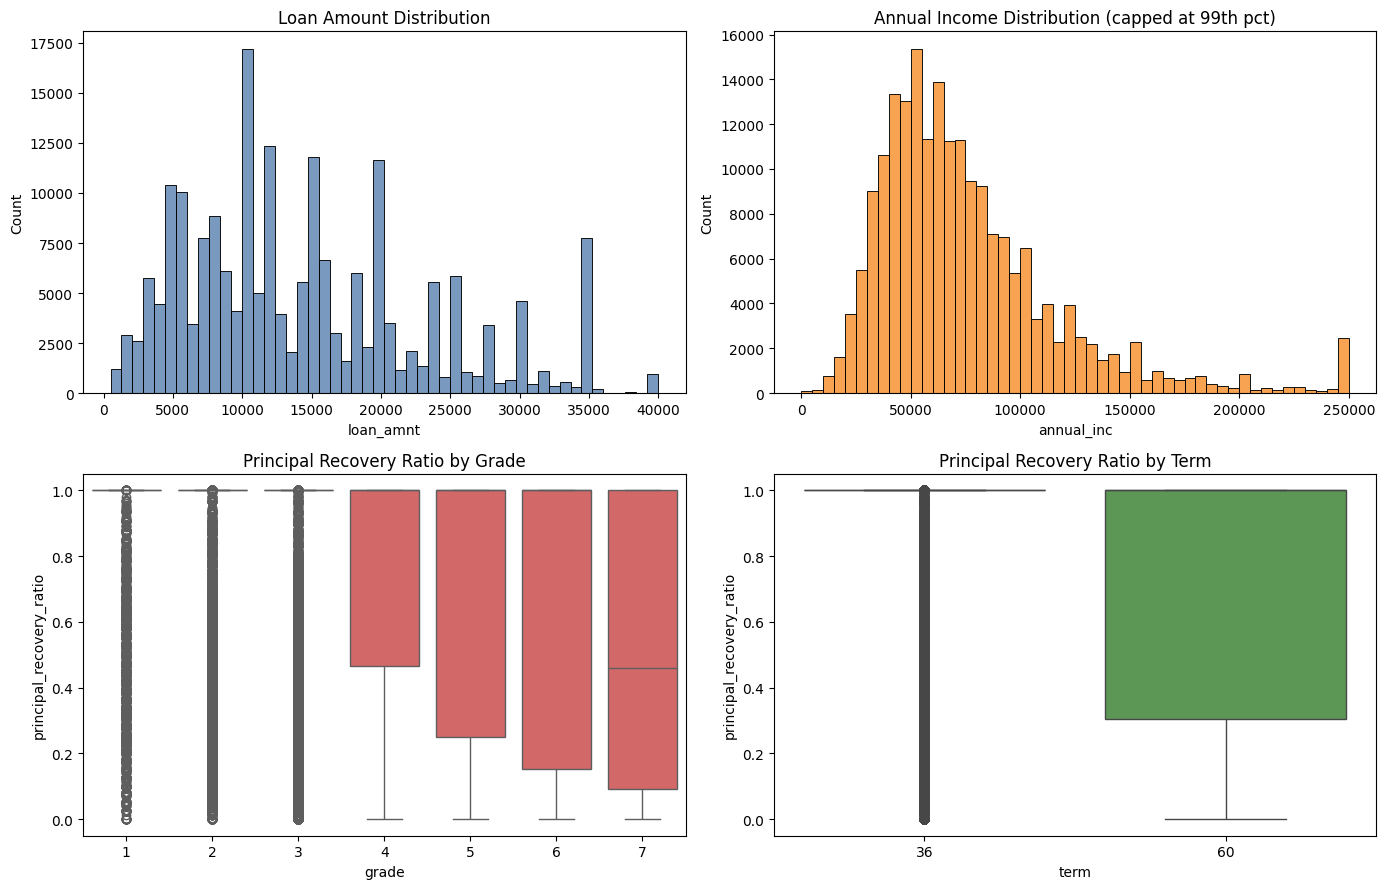


Mean principal recovery ratio by grade (top 15 rows):


,grade,principal_recovery_ratio
0,1,0.963870
1,2,0.915635
2,3,0.845933
3,4,0.779002
4,5,0.700908
5,6,0.630212
6,7,0.571755



Mean principal recovery ratio by sub_grade (top 15 rows):


,sub_grade,principal_recovery_ratio
0,1.0,0.981428
1,2.0,0.972273
2,3.0,0.966604
3,4.0,0.958859
4,5.0,0.949818
5,6.0,0.936142
6,7.0,0.930542
7,8.0,0.918622
8,9.0,0.906017
9,10.0,0.891227



Mean principal recovery ratio by term (top 15 rows):


,term,principal_recovery_ratio
0,36,0.896160
1,60,0.744048



Mean principal recovery ratio by emp_length (top 15 rows):


,emp_length,principal_recovery_ratio
10,10.0,0.868065
7,7.0,0.865467
6,6.0,0.863843
8,8.0,0.861658
5,5.0,0.861430
9,9.0,0.859974
4,4.0,0.859842
2,2.0,0.859390
3,3.0,0.858500
1,1.0,0.853987


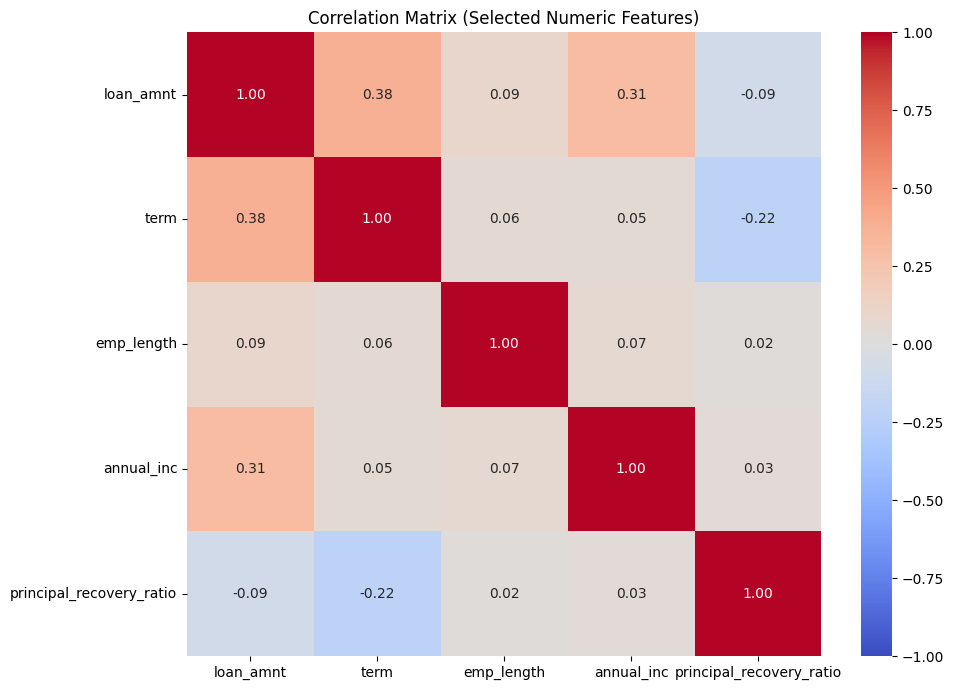

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

requested_eda_cols = [
    "loan_amnt", "loan_status", "grade", "sub_grade", "term",
    "emp_length", "annual_inc", "principal_recovery_ratio"
]
eda_cols = [c for c in requested_eda_cols if c in work.columns]
eda = work[eda_cols].copy()

print("EDA shape:", eda.shape)
print("EDA columns:", eda_cols)
print("Missing ratio (selected features):")
print(eda.isna().mean().sort_values(ascending=False).round(4))

# Keep plotting responsive on full dataset.
EDA_SAMPLE = 200000
plot_df = eda if len(eda) <= EDA_SAMPLE else eda.sample(EDA_SAMPLE, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if "loan_amnt" in plot_df.columns:
    sns.histplot(plot_df["loan_amnt"], bins=50, kde=False, ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].set_title("Loan Amount Distribution")
else:
    axes[0, 0].set_visible(False)

if "annual_inc" in plot_df.columns:
    annual_plot = plot_df["annual_inc"]
    annual_plot = annual_plot.clip(upper=annual_plot.quantile(0.99))
    sns.histplot(annual_plot, bins=50, kde=False, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Annual Income Distribution (capped at 99th pct)")
else:
    axes[0, 1].set_visible(False)

# Principal recovery ratio by grade and term
if "grade" in plot_df.columns and "principal_recovery_ratio" in plot_df.columns:
    sns.boxplot(data=plot_df, x="grade", y="principal_recovery_ratio", ax=axes[1, 0], color="#e45756")
    axes[1, 0].set_title("Principal Recovery Ratio by Grade")
    axes[1, 0].set_xlabel("grade")
else:
    axes[1, 0].set_visible(False)

if "term" in plot_df.columns and "principal_recovery_ratio" in plot_df.columns:
    sns.boxplot(data=plot_df, x="term", y="principal_recovery_ratio", ax=axes[1, 1], color="#54a24b")
    axes[1, 1].set_title("Principal Recovery Ratio by Term")
    axes[1, 1].set_xlabel("term")
else:
    axes[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Mean principal recovery ratio by categorical features.
cat_features = [c for c in ["grade", "sub_grade", "term", "emp_length"] if c in eda.columns]
for col in cat_features:
    if "principal_recovery_ratio" not in eda.columns:
        continue
    tmp = (
        eda[[col, "principal_recovery_ratio"]]
        .dropna()
        .groupby(col, as_index=False)["principal_recovery_ratio"]
        .mean()
        .sort_values("principal_recovery_ratio", ascending=False)
    )
    print(f"\nMean principal recovery ratio by {col} (top 15 rows):")
    display(tmp.head(15))

# Numeric correlation matrix for selected numeric fields.
num_for_corr_requested = ["loan_amnt", "term", "emp_length", "annual_inc", "principal_recovery_ratio"]
num_for_corr = [c for c in num_for_corr_requested if c in eda.columns]

if len(num_for_corr) >= 2:
    corr = eda[num_for_corr].corr(numeric_only=True)
    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Matrix (Selected Numeric Features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")


## 6) Random Train/Val/Test Split (IID)

We shuffle rows (`random_state=SEED_SPLIT`) and split 70/15/15 into train, validation, and test sets. This IID split mixes issue dates across splits, so it is useful for initial loan-level benchmarking but can be optimistic relative to forward-looking deployment.

The feature matrix excludes `loan_status`, `principal_recovery_ratio`, the backward-compatible `recovery_ratio` alias, `total_rec_prncp`, and `loan_amnt` to avoid leakage from outcome or target-construction fields.


In [23]:
MISSING_THRESHOLD = 0.40
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
SEED_SPLIT = 42

from sklearn.model_selection import train_test_split

missing_ratio = work.isna().mean()
high_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
work = work.drop(columns=high_missing, errors="ignore")

work = work[work["issue_d"].notna()].reset_index(drop=True)

y = work["principal_recovery_ratio"].copy()

X = work.drop(
    columns=["principal_recovery_ratio", "recovery_ratio", "total_rec_prncp", "loan_amnt", "loan_status"],
    errors="ignore",
).copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, train_size=TRAIN_RATIO, random_state=SEED_SPLIT, shuffle=True
)

val_frac_of_temp = VAL_RATIO / (1.0 - TRAIN_RATIO)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=val_frac_of_temp, random_state=SEED_SPLIT, shuffle=True
)

for frame in [X_train, X_val, X_test]:
    frame["issue_year"] = frame["issue_d"].dt.year
    frame["issue_month"] = frame["issue_d"].dt.month
    frame.drop(columns=["issue_d"], inplace=True)

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "mean_principal_recovery_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
})

summary


,split,rows,mean_principal_recovery_ratio
0,train,912546,0.859631
1,val,195545,0.858964
2,test,195547,0.858894


## 7) ColumnTransformer Preprocessing
- Numeric: median imputation + scaling
- Categorical: most-frequent imputation + one-hot encoding


In [24]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols))

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

X_train_arr = preprocessor.fit_transform(X_train)
X_val_arr = preprocessor.transform(X_val)
X_test_arr = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_prep = pd.DataFrame(X_train_arr, columns=feature_names)
X_val_prep = pd.DataFrame(X_val_arr, columns=feature_names)
X_test_prep = pd.DataFrame(X_test_arr, columns=feature_names)

print("Prepared shapes:")
print("X_train:", X_train_prep.shape)
print("X_val:", X_val_prep.shape)
print("X_test:", X_test_prep.shape)

Numeric cols: 23
Categorical cols: 6
Prepared shapes:
X_train: (912546, 101)
X_val: (195545, 101)
X_test: (195547, 101)


## 8) Export Processed Datasets

In [25]:
# Display-only mode: do not write output files.
print("Display-only mode enabled: no files will be written.")

print("\nPrepared dataset shapes:")
print("X_train:", X_train_prep.shape)
print("X_val:", X_val_prep.shape)
print("X_test:", X_test_prep.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nSplit summary:")
display(summary)

feature_df = pd.DataFrame({"feature": feature_names})
print("\nFeature count:", len(feature_df))
print("Feature sample (first 30):")
display(feature_df.head(30))


Display-only mode enabled: no files will be written.

Prepared dataset shapes:
X_train: (912546, 101)
X_val: (195545, 101)
X_test: (195547, 101)
y_train: (912546,)
y_val: (195545,)
y_test: (195547,)

Split summary:


,split,rows,mean_principal_recovery_ratio
0,train,912546,0.859631
1,val,195545,0.858964
2,test,195547,0.858894



Feature count: 101
Feature sample (first 30):


,feature
0,num__grade
1,num__sub_grade
2,num__term
3,num__emp_length
4,num__annual_inc
5,num__int_rate
6,num__installment
7,num__dti
8,num__open_acc
9,num__revol_util


## 9) Notes

- This pipeline predicts **principal recovery ratio** at the loan level.
- Principal recovery ratio is defined as `total_rec_prncp / loan_amnt`.
- Post-outcome columns are removed from the model features to avoid leakage.
- The random split is useful for baseline benchmarking, while the later time-based split is more realistic for vintage-based evaluation.
- MAE and RMSE are the main metrics. MAPE can be unstable when the target is close to zero.


## 10) Modeling Benchmarks (Non-Time-Series)

This section benchmarks loan-level tabular models for principal recovery ratio prediction:

1. **LinearRegression** as a simple linear baseline.
2. **XGBoost** as a nonlinear tree-based model using the preprocessed feature matrix.

The goal is to test whether borrower and loan-level features contain predictive signal for principal recovery. Metrics include MAE, RMSE, MAPE/MdAPE, and R², with MAE and RMSE used as the main headline metrics.


In [27]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 700,
    "max_depth": 4,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "random_state": SEED,
    "n_jobs": -1,
}

if "X_train_prep" not in globals():
    raise RuntimeError("X_train_prep not found. Re-run preprocessing cells before modeling.")

required_expanded_tokens = [
    "num__int_rate",
    "num__dti",
    "cat__home_ownership_RENT",
]
present_feature_names = list(X_train_prep.columns)
missing_tokens = [t for t in required_expanded_tokens if t not in present_feature_names]
print(f"Modeling with {len(present_feature_names)} features (fixed hyperparameters)")
if missing_tokens:
    raise RuntimeError(
        "Expanded features are not reflected in X_train_prep. "
        f"Missing: {missing_tokens}. Re-run from target/cleaning/preprocessing cells."
    )

Xtr = X_train_prep.values
Xva = X_val_prep.values
Xte = X_test_prep.values

ytr = np.asarray(y_train)
yva = np.asarray(y_val)
yte = np.asarray(y_test)


def evaluate_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE / MdAPE: only |y_true| >= 0.01 (1% recovery); tiny y makes relative error meaningless.
    min_abs_y = 0.01
    mask = np.abs(y_true) >= min_abs_y
    if np.any(mask):
        rel = np.abs((y_true[mask] - y_pred[mask]) / np.abs(y_true[mask]))
        mape = float(np.mean(rel) * 100)
        mdape = float(np.median(rel) * 100)
    else:
        mape = float("nan")
        mdape = float("nan")
    return mae, rmse, r2, mape, mdape


linreg = LinearRegression()
linreg.fit(Xtr, ytr)

xgb_model = None
try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(**XGB_PARAMS)
    xgb_model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    print("Trained: LinearRegression + XGBRegressor")
except Exception as e:
    print("XGBoost unavailable; LinearRegression only. Reason:", e)

models = {"LinearRegression": linreg}
if xgb_model is not None:
    models["XGBRegressor"] = xgb_model

rows = []
for name, model in models.items():
    pred_val = model.predict(Xva)
    pred_test = model.predict(Xte)

    val_mae, val_rmse, val_r2, val_mape, val_mdape = evaluate_predictions(yva, pred_val)
    test_mae, test_rmse, test_r2, test_mape, test_mdape = evaluate_predictions(yte, pred_test)

    rows.append(
        {
            "model": name,
            "val_mae": val_mae,
            "val_rmse": val_rmse,
            "val_mape": val_mape,
            "val_mdape": val_mdape,
            "val_r2": val_r2,
            "test_mae": test_mae,
            "test_rmse": test_rmse,
            "test_mape": test_mape,
            "test_mdape": test_mdape,
            "test_r2": test_r2,
        }
    )

results_df = pd.DataFrame(rows).sort_values("test_mae", ascending=True).reset_index(drop=True)

print("\nModel comparison (sorted by test MAE):")
display(results_df)


Modeling with 101 features (fixed hyperparameters)
Trained: LinearRegression + XGBRegressor

Model comparison (sorted by test MAE):


,model,val_mae,val_rmse,val_mape,val_mdape,val_r2,test_mae,test_rmse,test_mape,test_mdape,test_r2
0,XGBRegressor,0.196768,0.274730,94.080100,12.633818,0.143302,0.196950,0.274943,93.858843,12.612247,0.141984
1,LinearRegression,0.204113,0.278907,96.936624,14.260101,0.117049,0.204203,0.279029,96.816201,14.230347,0.116293


## 11) XGBoost Feature Importance

The XGBoost feature importance results provide evidence that the model is learning meaningful credit-risk signals rather than random noise. The most important predictors are `sub_grade`, `grade`, and `term`, which are directly related to borrower risk and loan structure. This aligns with the EDA results, where lower credit grades and 60-month loans showed substantially lower average principal recovery ratios.

Other important features, including `int_rate`, `dti`, `inq_last_6mths`, `pub_rec`, `annual_inc`, `mort_acc`, `home_ownership`, and `verification_status`, are also economically reasonable because they capture borrower credit quality, debt burden, financial stability, and verification strength. The importance of `issue_year` further suggests that recovery outcomes vary across lending vintages.



Feature importances (XGBoost):


,Feature,Importance
1,sub_grade,0.207996
0,grade,0.160590
2,term,0.091434
28,home_ownership_RENT,0.037024
17,mort_acc,0.035086
21,issue_year,0.033307
24,home_ownership_MORTGAGE,0.030065
5,int_rate,0.023115
29,verification_status_Not Verified,0.020471
7,dti,0.015668


/var/folders/sk/0y5rgg2d51zfvpscpflvxh0h0000gn/T/ipykernel_62072/2444259145.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


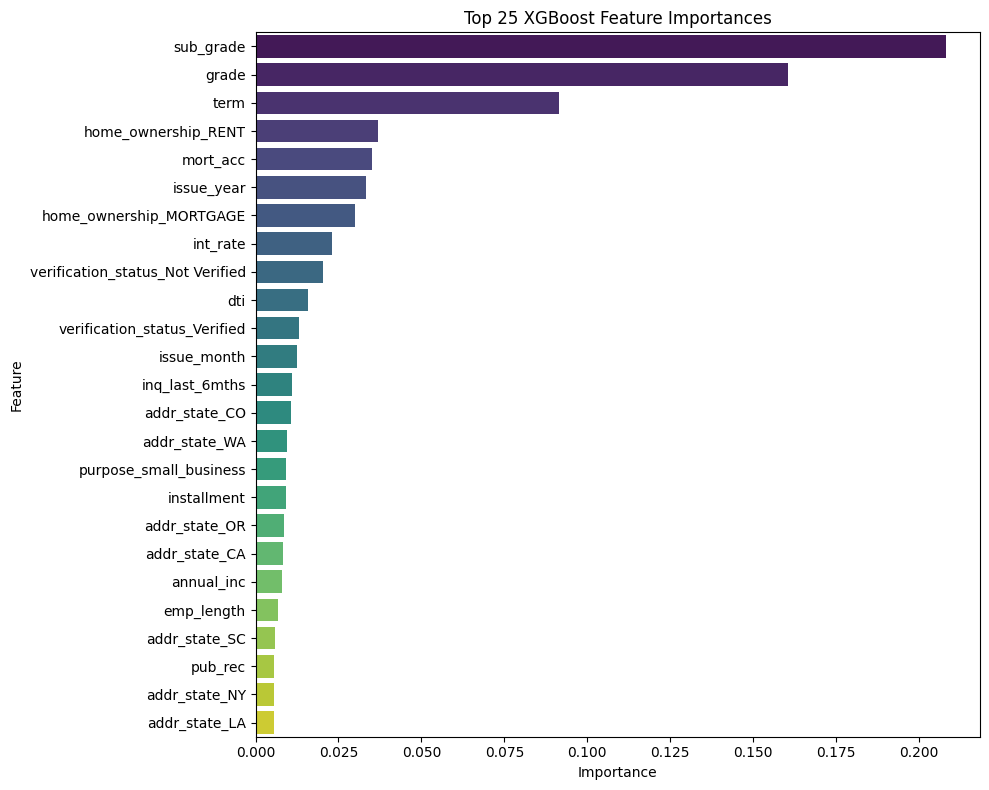

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

if "xgb_model" in globals() and xgb_model is not None:
    feature_importances = xgb_model.feature_importances_

    original_feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    importance_df = pd.DataFrame({
        "Feature": original_feature_names,
        "Importance": feature_importances
    }).sort_values(by="Importance", ascending=False)

    print("\nFeature importances (XGBoost):")
    display(importance_df.head(25))

    plt.figure(figsize=(10, 8))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df.head(25),
        palette="viridis"
    )
    plt.title("Top 25 XGBoost Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print("No XGBoost model found. Run the modeling cell above successfully first.")



## 12) Target Sanity Check Before LSTM Sections

After filtering the dataset to closed loans only (`Fully Paid`, `Charged Off`, and `Default`), the modeling sample contains 1,303,638 observations. The target variable is `principal_recovery_ratio = total_rec_prncp / loan_amnt`, which measures the proportion of original loan principal recovered.

The resulting target distribution is reasonable, with a mean principal recovery ratio of approximately 0.8594 and values ranging from 0 to approximately 1. This confirms that the target is bounded and economically interpretable.


In [29]:
FINAL_STATUSES = {"Fully Paid", "Charged Off", "Default"}

# Modeling features only (no target-related columns).
SELECTED_FEATURES = [
    "loan_amnt",
    "grade",
    "sub_grade",
    "term",
    "emp_length",
    "annual_inc",
    "int_rate",
    "installment",
    "home_ownership",
    "dti",
    "earliest_cr_line",
    "open_acc",
    "revol_util",
    "verification_status",
    "purpose",
    "addr_state",
    "delinq_2yrs",
    "inq_last_6mths",
    "pub_rec",
    "revol_bal",
    "total_acc",
    "initial_list_status",
    "collections_12_mths_ex_med",
    "application_type",
    "acc_now_delinq",
    "mort_acc",
    "pub_rec_bankruptcies",
    "tax_liens",
]

SPLIT_COL = "issue_d"
TARGET_COLS = ["total_rec_prncp", "loan_amnt"]

available_features = [c for c in SELECTED_FEATURES if c in df.columns]
missing_features = [c for c in SELECTED_FEATURES if c not in df.columns]

if SPLIT_COL not in df.columns:
    raise ValueError(f"Missing required split column: {SPLIT_COL}")

for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f"Missing required column for principal_recovery_ratio: {col}")

if missing_features:
    print("[WARN] Missing requested features in this dataset:", missing_features)

base_cols = list(dict.fromkeys(available_features + [SPLIT_COL] + TARGET_COLS + ["loan_status"]))
base = df[[c for c in base_cols if c in df.columns]].copy()
base = base[base["loan_status"].isin(FINAL_STATUSES)].copy()

# Ensure numeric and valid for division
base["total_rec_prncp"] = pd.to_numeric(base["total_rec_prncp"], errors="coerce")
base["loan_amnt"] = pd.to_numeric(base["loan_amnt"], errors="coerce")
base = base[base["loan_amnt"] > 0].copy()

# Main target: principal recovered relative to original loan principal.
base["principal_recovery_ratio"] = base["total_rec_prncp"] / base["loan_amnt"]

# Backward-compatible alias for existing downstream monthly/LSTM code.
base["recovery_ratio"] = base["principal_recovery_ratio"]

print("Rows after target filtering:", len(base))
print("Principal recovery ratio stats: mean = {:.4f}, min = {:.4f}, max = {:.4f}".format(
    base["principal_recovery_ratio"].mean(),
    base["principal_recovery_ratio"].min(),
    base["principal_recovery_ratio"].max()
))
print("Included statuses:", FINAL_STATUSES)
print("Requested features:", SELECTED_FEATURES)



Rows after target filtering: 1303638
Principal recovery ratio stats: mean = 0.8594, min = 0.0000, max = 1.0000
Included statuses: {'Fully Paid', 'Charged Off', 'Default'}
Requested features: ['loan_amnt', 'grade', 'sub_grade', 'term', 'emp_length', 'annual_inc', 'int_rate', 'installment', 'home_ownership', 'dti', 'earliest_cr_line', 'open_acc', 'revol_util', 'verification_status', 'purpose', 'addr_state', 'delinq_2yrs', 'inq_last_6mths', 'pub_rec', 'revol_bal', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


## 13) Monthly LSTM Forecast

This section builds a monthly cohort time series from `work` and trains an LSTM to forecast next-month average principal recovery ratio. The monthly target column is named `mean_recovery_ratio` for backward compatibility with earlier code, but it is based on `principal_recovery_ratio`.

Because there are only about 138 monthly observations, this model should be interpreted as an exploratory time-series benchmark rather than the main production model.


In [9]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# LSTM settings
SEQ_LEN = 12
HIDDEN_SIZE = 24
DROPOUT = 0.25
BATCH_SIZE = 8
LR = 3e-4
MAX_EPOCHS = 220
PATIENCE = 25
USE_LOG1P_TARGET = True
print('TensorFlow:', tf.__version__)


TensorFlow: 2.18.1


In [10]:
if 'work' not in globals():
    raise RuntimeError('`work` not found. Run preprocessing cells above first.')

w = work.copy()
if not np.issubdtype(w['issue_d'].dtype, np.datetime64):
    w['issue_d'] = pd.to_datetime(w['issue_d'], errors='coerce')
w = w[w['issue_d'].notna()].copy()

w['issue_year'] = w['issue_d'].dt.year
w['issue_month'] = w['issue_d'].dt.month

# Candidate loan-level inputs -> monthly cohort features
feature_candidates = [
    'recovery_ratio', 'grade', 'sub_grade', 'term', 'emp_length',
    'annual_inc', 'int_rate', 'dti'
]
available = [c for c in feature_candidates if c in w.columns]
for c in available:
    w[c] = pd.to_numeric(w[c], errors='coerce')

monthly = (
    w.groupby(['issue_year', 'issue_month'])
     .agg(
         mean_recovery_ratio=('recovery_ratio', 'mean'),
         mean_grade=('grade', 'mean') if 'grade' in w.columns else ('recovery_ratio', 'mean'),
         mean_sub_grade=('sub_grade', 'mean') if 'sub_grade' in w.columns else ('recovery_ratio', 'mean'),
         frac_60mo=('term', lambda x: np.mean(x == 60)) if 'term' in w.columns else ('recovery_ratio', 'size'),
         mean_emp_length=('emp_length', 'mean') if 'emp_length' in w.columns else ('recovery_ratio', 'mean'),
         mean_annual_inc=('annual_inc', 'mean') if 'annual_inc' in w.columns else ('recovery_ratio', 'mean'),
         loan_count=('recovery_ratio', 'count'),
     )
     .reset_index()
     .sort_values(['issue_year', 'issue_month'])
     .reset_index(drop=True)
)

monthly['issue_date'] = pd.to_datetime(dict(year=monthly['issue_year'], month=monthly['issue_month'], day=1))
monthly['t_idx'] = np.arange(len(monthly), dtype=float)
monthly['month_sin'] = np.sin(2 * np.pi * monthly['issue_month'] / 12.0)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['issue_month'] / 12.0)
monthly['rr_mom_1m'] = monthly['mean_recovery_ratio'].diff()
monthly['rr_rolling_3m'] = monthly['mean_recovery_ratio'].rolling(3, min_periods=1).mean()

FEATURE_COLS = [
    'mean_recovery_ratio', 'mean_grade', 'mean_sub_grade', 'frac_60mo',
    'mean_emp_length', 'mean_annual_inc', 'loan_count',
    't_idx', 'month_sin', 'month_cos', 'rr_mom_1m', 'rr_rolling_3m'
]
TARGET_COL = 'mean_recovery_ratio'
monthly = monthly.dropna(subset=FEATURE_COLS).reset_index(drop=True)

n = len(monthly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)
train_raw = monthly.iloc[:train_end]
val_raw = monthly.iloc[train_end:val_end]
test_raw = monthly.iloc[val_end:]

feat_scaler = StandardScaler()
train_proc, val_proc, test_proc = train_raw.copy(), val_raw.copy(), test_raw.copy()
if USE_LOG1P_TARGET:
    for d in [train_proc, val_proc, test_proc]:
        d[TARGET_COL] = np.log1p(d[TARGET_COL].clip(lower=0))

feat_scaler.fit(train_proc[FEATURE_COLS])
train_scaled, val_scaled, test_scaled = train_proc.copy(), val_proc.copy(), test_proc.copy()
train_scaled[FEATURE_COLS] = feat_scaler.transform(train_proc[FEATURE_COLS])
val_scaled[FEATURE_COLS] = feat_scaler.transform(val_proc[FEATURE_COLS])
test_scaled[FEATURE_COLS] = feat_scaler.transform(test_proc[FEATURE_COLS])

print(f'Monthly cohorts: {len(monthly)} | Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}')


Monthly cohorts: 138 | Train: 96 | Val: 21 | Test: 21


### Monthly Principal Recovery Trend

This plot shows how the cohort-level mean principal recovery ratio changes over calendar time, with split boundaries marked. If the level or trend shifts by loan vintage, random splits can overestimate performance relative to chronological forecasting.


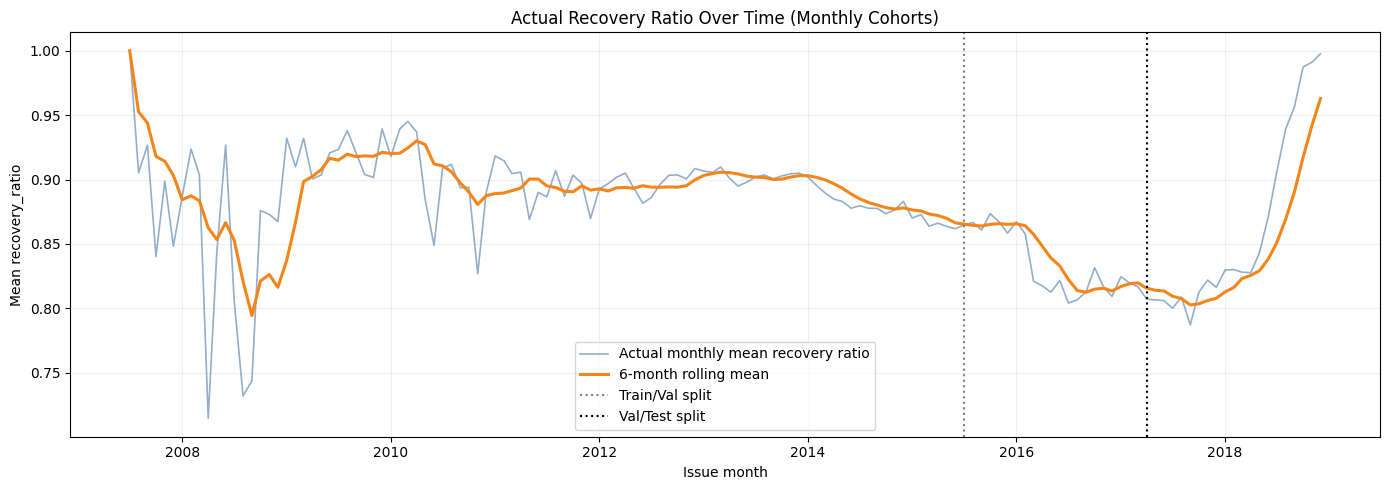

In [11]:
monthly_plot = monthly.copy()
monthly_plot['rr_rolling_6m'] = monthly_plot['mean_recovery_ratio'].rolling(window=6, min_periods=1).mean()

n = len(monthly_plot)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_plot['issue_date'], monthly_plot['mean_recovery_ratio'],
        color='#4c78a8', linewidth=1.2, alpha=0.6, label='Actual monthly mean recovery ratio')
ax.plot(monthly_plot['issue_date'], monthly_plot['rr_rolling_6m'],
        color='#f58518', linewidth=2.2, label='6-month rolling mean')

ax.axvline(monthly_plot['issue_date'].iloc[train_end], color='grey', linestyle=':', linewidth=1.5, label='Train/Val split')
ax.axvline(monthly_plot['issue_date'].iloc[val_end], color='black', linestyle=':', linewidth=1.5, label='Val/Test split')

ax.set_title('Actual Recovery Ratio Over Time (Monthly Cohorts)')
ax.set_xlabel('Issue month')
ax.set_ylabel('Mean recovery_ratio')
ax.grid(alpha=0.2)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [12]:
def build_sequences(context_df, target_df, seq_len, feature_cols, target_col):
    full = pd.concat([context_df, target_df], ignore_index=True)
    feats = full[feature_cols].values.astype(np.float32)
    targets = full[target_col].values.astype(np.float32)
    n_context = len(context_df)
    X, y = [], []
    for i in range(n_context, len(full)):
        if i - seq_len < 0:
            continue
        X.append(feats[i-seq_len:i])
        y.append(targets[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = build_sequences(train_scaled.iloc[:SEQ_LEN], train_scaled.iloc[SEQ_LEN:], SEQ_LEN, FEATURE_COLS, TARGET_COL)
X_val, y_val = build_sequences(train_scaled.iloc[-SEQ_LEN:], val_scaled, SEQ_LEN, FEATURE_COLS, TARGET_COL)
X_test, y_test = build_sequences(val_scaled.iloc[-SEQ_LEN:], test_scaled, SEQ_LEN, FEATURE_COLS, TARGET_COL)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


X_train: (84, 12, 12) y_train: (84,)
X_val  : (21, 12, 12) y_val  : (21,)
X_test : (21, 12, 12) y_test : (21,)


In [13]:
model_lstm = keras.Sequential([
    keras.Input(shape=(SEQ_LEN, len(FEATURE_COLS))),
    layers.LSTM(HIDDEN_SIZE, return_sequences=False, dropout=DROPOUT),
    layers.Dense(16, activation='relu'),
    layers.Dropout(DROPOUT),
    layers.Dense(1),
], name='LSTM_Integrated')

model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=1.0),
    loss='mae',
    metrics=['mae', 'mse'],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_mae', mode='min', patience=PATIENCE, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_mae', mode='min', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
]

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/220


2026-04-09 20:12:11.526357: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-09 20:12:11.526786: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5682 - mae: 0.5682 - mse: 0.7670 - val_loss: 1.5464 - val_mae: 1.5464 - val_mse: 2.7117 - learning_rate: 3.0000e-04
Epoch 2/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5738 - mae: 0.5738 - mse: 0.7507 - val_loss: 1.5039 - val_mae: 1.5039 - val_mse: 2.5846 - learning_rate: 3.0000e-04
Epoch 3/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5414 - mae: 0.5414 - mse: 0.7322 - val_loss: 1.4565 - val_mae: 1.4565 - val_mse: 2.4484 - learning_rate: 3.0000e-04
Epoch 4/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5510 - mae: 0.5510 - mse: 0.7501 - val_loss: 1.4207 - val_mae: 1.4207 - val_mse: 2.3516 - learning_rate: 3.0000e-04
Epoch 5/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5374 - mae: 0.5374 - mse: 0.7775 - val_loss: 1.3867 - val_mae: 1.3867 - val_mse: 2.2589 - learning_rate: 3.0000e-04
Epoch 6/220
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5190 - mae: 0.5190 - mse: 0.6498 - val_loss: 1.3449 - val_mae: 1.

[Integrated LSTM] Val MAE=0.0206 RMSE=0.0222
[Integrated LSTM] Test MAE=0.0393 RMSE=0.0529


2026-04-09 20:12:20.156778: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-09 20:12:20.157248: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

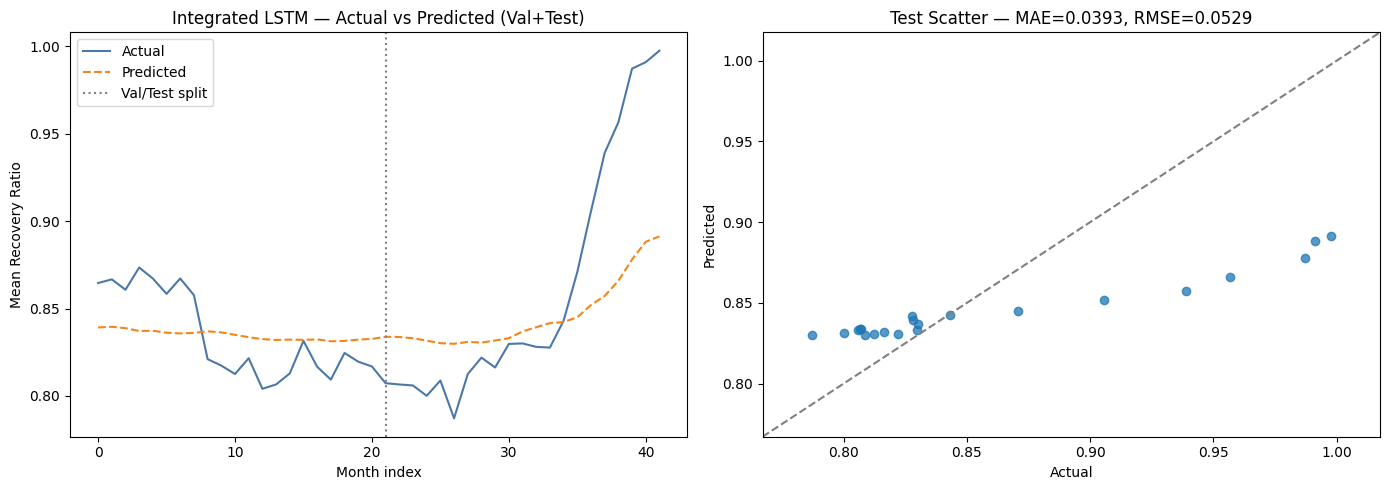

In [14]:
def inv_target(arr_scaled):
    idx = FEATURE_COLS.index(TARGET_COL)
    mean, std = feat_scaler.mean_[idx], feat_scaler.scale_[idx]
    raw = arr_scaled * std + mean
    return np.expm1(raw) if USE_LOG1P_TARGET else raw

v_pred_raw = inv_target(model_lstm.predict(X_val, verbose=0).flatten())
t_pred_raw = inv_target(model_lstm.predict(X_test, verbose=0).flatten())
v_true = inv_target(y_val)
t_true = inv_target(y_test)

# simple validation bias shift
val_bias = float(np.mean(v_pred_raw - v_true))
v_pred = np.clip(v_pred_raw - val_bias, 0.0, None)
t_pred = np.clip(t_pred_raw - val_bias, 0.0, None)

val_mae = mean_absolute_error(v_true, v_pred)
test_mae = mean_absolute_error(t_true, t_pred)
val_rmse = np.sqrt(mean_squared_error(v_true, v_pred))
test_rmse = np.sqrt(mean_squared_error(t_true, t_pred))

print(f'[Integrated LSTM] Val MAE={val_mae:.4f} RMSE={val_rmse:.4f}')
print(f'[Integrated LSTM] Test MAE={test_mae:.4f} RMSE={test_rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
all_true = np.concatenate([v_true, t_true])
all_pred = np.concatenate([v_pred, t_pred])
x = np.arange(len(all_true))
axes[0].plot(x, all_true, label='Actual', color='#4c78a8')
axes[0].plot(x, all_pred, '--', label='Predicted', color='#f58518')
axes[0].axvline(len(v_true), color='grey', linestyle=':', label='Val/Test split')
axes[0].set_title('Integrated LSTM — Actual vs Predicted (Val+Test)')
axes[0].set_xlabel('Month index')
axes[0].set_ylabel('Mean Recovery Ratio')
axes[0].legend()

axes[1].scatter(t_true, t_pred, alpha=0.75)
lim0 = min(t_true.min(), t_pred.min()) - 0.02
lim1 = max(t_true.max(), t_pred.max()) + 0.02
axes[1].plot([lim0, lim1], [lim0, lim1], '--', color='grey')
axes[1].set_xlim([lim0, lim1]); axes[1].set_ylim([lim0, lim1])
axes[1].set_title(f'Test Scatter — MAE={test_mae:.4f}, RMSE={test_rmse:.4f}')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
plt.tight_layout(); plt.show()


## 14) Loan-Level LSTM With Time-Based Split

This section evaluates a loan-level LSTM using a chronological train/validation/test split based on `issue_d`. Unlike the earlier random split, this setup better reflects a forward-looking prediction task where the model is trained on earlier loan vintages and evaluated on later vintages.

The target remains `principal_recovery_ratio = total_rec_prncp / loan_amnt`. Outcome-related columns such as `loan_status`, `total_rec_prncp`, `principal_recovery_ratio`, and the backward-compatible `recovery_ratio` alias are excluded from the feature matrix to avoid leakage.

Because each loan is represented as a single row rather than a natural sequence, this loan-level LSTM uses one timestep per loan. Therefore, it should be interpreted as a neural-network benchmark for tabular loan-level prediction, not as a true temporal sequence model.


In [16]:
MISSING_THRESHOLD = 0.40
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Drop high-missing columns first
missing_ratio = work.isna().mean()
high_missing = missing_ratio[missing_ratio > MISSING_THRESHOLD].index.tolist()
work = work.drop(columns=high_missing, errors="ignore")

work = work[work["issue_d"].notna()].sort_values("issue_d").reset_index(drop=True)

y = work["principal_recovery_ratio"].copy()

# Avoid data leakage: exclude loan_status, target aliases, target-building columns, and loan amount.
X = work.drop(
    columns=[
        "principal_recovery_ratio",
        "recovery_ratio",
        "total_rec_prncp",
        "loan_amnt",
        "loan_status",
    ],
    errors="ignore",
).copy()

n = len(X)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

y_train = y.iloc[:train_end].copy()
y_val = y.iloc[train_end:val_end].copy()
y_test = y.iloc[val_end:].copy()

for frame in [X_train, X_val, X_test]:
    frame["issue_year"] = frame["issue_d"].dt.year
    frame["issue_month"] = frame["issue_d"].dt.month
    frame.drop(columns=["issue_d"], inplace=True)

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "mean_principal_recovery_ratio": [y_train.mean(), y_val.mean(), y_test.mean()],
})

summary



,split,rows,mean_principal_recovery_ratio
0,train,912546,0.876635
1,val,195546,0.815947
2,test,195546,0.822563


### Loan-Level LSTM Input Preparation

This preprocessing step converts the loan-level tabular data into the 3D format required by Keras LSTM layers. Since each loan is represented by one observation rather than a sequence, we use one timestep per loan: `(samples, 1, features)`.


In [17]:
import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Build loan-level preprocessing on this split
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor_ll = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

Xtr_arr = preprocessor_ll.fit_transform(X_train)
Xva_arr = preprocessor_ll.transform(X_val)
Xte_arr = preprocessor_ll.transform(X_test)

# LSTM expects 3D: (samples, timesteps, features).
# For loan-level rows (no natural sequence), use a single timestep per loan.
Xtr_lstm = Xtr_arr[:, np.newaxis, :].astype(np.float32)
Xva_lstm = Xva_arr[:, np.newaxis, :].astype(np.float32)
Xte_lstm = Xte_arr[:, np.newaxis, :].astype(np.float32)

ytr = np.asarray(y_train, dtype=np.float32)
yva = np.asarray(y_val, dtype=np.float32)
yte = np.asarray(y_test, dtype=np.float32)

print("Loan-level LSTM shapes:")
print("Xtr_lstm:", Xtr_lstm.shape, "Xva_lstm:", Xva_lstm.shape, "Xte_lstm:", Xte_lstm.shape)


Loan-level LSTM shapes:
Xtr_lstm: (912546, 1, 101) Xva_lstm: (195546, 1, 101) Xte_lstm: (195546, 1, 101)


### Loan-Level LSTM Training

The loan-level LSTM is included as a neural-network benchmark on tabular loan-level features. Since each loan has one timestep, this model does not learn within-loan temporal dynamics; it tests whether a neural architecture can capture nonlinear relationships in the loan-level feature set.


In [18]:
loan_lstm = keras.Sequential([
    keras.Input(shape=(1, Xtr_lstm.shape[2])),
    layers.LSTM(32, return_sequences=False, dropout=0.2),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1),
], name="LoanLevel_LSTM")

loan_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss="mae",
    metrics=["mae", "mse"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=8, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_mae", mode="min", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

hist_ll = loan_lstm.fit(
    Xtr_lstm, ytr,
    validation_data=(Xva_lstm, yva),
    epochs=60,
    batch_size=512,
    shuffle=False,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60


2026-04-09 20:18:03.238118: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2026-04-09 20:18:03.238590: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

1783/1783 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2374 - mae: 0.2374 - mse: 0.1099 - val_loss: 0.2161 - val_mae: 0.2161 - val_mse: 0.1079 - learning_rate: 3.0000e-04
Epoch 2/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1777 - mae: 0.1777 - mse: 0.0846 - val_loss: 0.2006 - val_mae: 0.2006 - val_mse: 0.1205 - learning_rate: 3.0000e-04
Epoch 3/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1421 - mae: 0.1421 - mse: 0.0867 - val_loss: 0.1858 - val_mae: 0.1858 - val_mse: 0.1403 - learning_rate: 3.0000e-04
Epoch 4/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1236 - mae: 0.1236 - mse: 0.0902 - val_loss: 0.1840 - val_mae: 0.1840 - val_mse: 0.1419 - learning_rate: 3.0000e-04
Epoch 5/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1233 - mae: 0.1233 - mse: 0.0895 - val_loss: 0.1831 - val_mae: 0.1831 - val_mse: 0.1317 - learning_rate: 3.0000e-04
Epoch 6/60
1783/1783 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1227 - mae: 0.1227 - mse: 0.0870 - val_loss: 0.

### Loan-Level LSTM Training Interpretation

During training, the loan-level LSTM reached a best validation MAE of approximately 0.181, compared with a training MAE around 0.122. The validation MAE is lower than the XGBoost validation MAE of about 0.197, suggesting that the neural-network benchmark captures additional nonlinear signal from the loan-level feature set.

The gap between training and validation MAE indicates either some overfitting or distribution shift across loan vintages, so the held-out test result should be used for the final comparison.


In [19]:
pred_val = loan_lstm.predict(Xva_lstm, verbose=0).flatten()
pred_test = loan_lstm.predict(Xte_lstm, verbose=0).flatten()

val_mae_ll = mean_absolute_error(yva, pred_val)
val_rmse_ll = np.sqrt(mean_squared_error(yva, pred_val))
test_mae_ll = mean_absolute_error(yte, pred_test)
test_rmse_ll = np.sqrt(mean_squared_error(yte, pred_test))
test_bias_ll = float(np.mean(pred_test - yte))

print(f"Loan-level LSTM | Val MAE={val_mae_ll:.4f} RMSE={val_rmse_ll:.4f}")
print(f"Loan-level LSTM | Test MAE={test_mae_ll:.4f} RMSE={test_rmse_ll:.4f} bias={test_bias_ll:+.4f}")


2026-04-09 20:20:40.813952: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-04-09 20:20:40.814357: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

Loan-level LSTM | Val MAE=0.1804 RMSE=0.3585
Loan-level LSTM | Test MAE=0.1776 RMSE=0.3762 bias=+0.1486


## 15) Final Loan-Level LSTM Evaluation

The loan-level LSTM achieved the lowest test MAE among the loan-level models, reducing test MAE from 0.197 for XGBoost to 0.178. This suggests that the neural-network model captures additional nonlinear signal in borrower and loan characteristics.

However, the model has a positive test bias of about +0.149, meaning it tends to overestimate principal recovery. Therefore, while the LSTM improves average absolute error, further calibration or loss reweighting would be needed before treating it as a production-ready model.
